# LOBSTER Limit Order Book EDA — AAPL, 2012-06-21 (10 levels)

## What is a Limit Order Book (LOB)?

A limit order book is the ledger an exchange keeps of all resting (unfilled) buy and sell
orders for one stock, sorted by price:

- **Bids** (buy orders) sorted from highest to lowest price — the highest bid is the
  **best bid**, the price a buyer is currently willing to pay.
- **Asks / offers** (sell orders) sorted from lowest to highest price — the lowest ask is
  the **best ask**, the price a seller is currently willing to accept.
- The gap between best bid and best ask is the **spread**; their average is the
  **mid-price**, the standard reference price for the stock at that instant.

Every new order, cancellation, or trade changes this book. LOBSTER reconstructs the full
book from raw NASDAQ TotalView-ITCH messages, giving us, for every single event, both
**what happened** (the message) and **the resulting state of the book** (the snapshot).

## The dataset

This sample covers **AAPL on 2012-06-21**, the **full regular trading session**
(09:30:00–16:00:00 ET, timestamps in seconds after midnight), reconstructed to
**10 price levels** on each side. Two files, row-aligned 1:1 (row *i* of the orderbook
file is the book state immediately *after* row *i* of the message file is applied):

**Message file** — one row per event:

| col | name | meaning |
|---|---|---|
| 1 | `time` | seconds after midnight, nanosecond precision |
| 2 | `event_type` | 1=New limit order, 2=Partial cancel, 3=Full delete, 4=Visible execution, 5=Hidden execution, 7=Trading halt |
| 3 | `order_id` | unique resting-order identifier |
| 4 | `size` | number of shares |
| 5 | `price` | in **fixed point**, price × 10,000 |
| 6 | `direction` | -1 = sell-side order / sell-initiated trade, 1 = buy-side order / buy-initiated trade |

**Orderbook file** — one row per event, book state after that event:

`ask_price_1, ask_size_1, bid_price_1, bid_size_1, ask_price_2, ask_size_2, ...` up to
level 10. Prices are fixed-point (× 10,000) exactly like the message file.

> Note: execution direction is recorded from the perspective of the **resting (limit)
> order being hit**, not the aggressor. `direction = -1` on an execution means a sell
> limit order was hit, i.e. the trade was **buyer-initiated**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DATA_DIR = "LOBSTER_SampleFile_AAPL_2012-06-21_10"
MSG_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_message_10.csv"
OB_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"
N_LEVELS = 10
TICK = 0.01  # NASDAQ minimum tick size for stocks > $1

EVENT_TYPE_LABELS = {
    1: "New limit order",
    2: "Partial cancel",
    3: "Full delete",
    4: "Execution (visible)",
    5: "Execution (hidden)",
    7: "Trading halt",
}


## 1. Load the data

Neither file ships column headers, so we supply them explicitly and immediately rescale
prices from LOBSTER's fixed-point integers (× 10,000) to dollars. We also convert `time`
(seconds after midnight) into a proper time-of-day for readable axes.

In [2]:
msg_cols = ["time", "event_type", "order_id", "size", "price", "direction"]

ob_cols = []
for lvl in range(1, N_LEVELS + 1):
    ob_cols += [f"ask_price_{lvl}", f"ask_size_{lvl}", f"bid_price_{lvl}", f"bid_size_{lvl}"]

df_msg = pd.read_csv(MSG_FILE, names=msg_cols)
df_ob = pd.read_csv(OB_FILE, names=ob_cols)

assert len(df_msg) == len(df_ob), "message and orderbook files must be row-aligned"

# Rescale fixed-point prices (x10,000) to dollars
df_msg["price"] = df_msg["price"] / 10_000
price_cols = [c for c in df_ob.columns if "price" in c]
df_ob[price_cols] = df_ob[price_cols] / 10_000

# Human-readable time-of-day, still keeping the original float seconds for arithmetic
df_msg["time_sec"] = df_msg["time"]
df_msg["time"] = pd.to_datetime(df_msg["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
df_msg["event_label"] = df_msg["event_type"].map(EVENT_TYPE_LABELS)

# One combined frame: each row = an event + the resulting book state
df = pd.concat([df_msg, df_ob], axis=1)

print(f"{len(df):,} events from {df_msg['time'].min().time()} to {df_msg['time'].max().time()}")
df.head()

400,391 events from 09:30:00.004241 to 15:59:59.913117


,time,event_type,order_id,size,price,direction,time_sec,event_label,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,bid_price_3,bid_size_3,ask_price_4,ask_size_4,bid_price_4,bid_size_4,ask_price_5,ask_size_5,bid_price_5,bid_size_5,ask_price_6,ask_size_6,bid_price_6,bid_size_6,ask_price_7,ask_size_7,bid_price_7,bid_size_7,ask_price_8,ask_size_8,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,2012-06-21 09:30:00.004241228,1,16113575,18,585.33,1,34200.004241,New limit order,585.94,200,585.33,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300,587.65,1160,584.38,200,587.90,500,584.27,300
1,2012-06-21 09:30:00.004260540,1,16113584,18,585.32,1,34200.004261,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300,587.90,500,584.38,200
2,2012-06-21 09:30:00.004447460,1,16113594,18,585.31,1,34200.004447,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.31,18,586.89,300,585.30,150,586.95,50,585.10,5,587.00,100,585.01,89,587.10,10,584.97,5,587.39,100,584.93,300,587.65,1160,584.65,300,587.90,500,584.53,300
3,2012-06-21 09:30:00.025551796,1,16120456,18,585.91,-1,34200.025552,New limit order,585.91,18,585.33,18,585.94,200,585.32,18,585.98,200,585.31,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300
4,2012-06-21 09:30:00.025579453,1,16120480,18,585.92,-1,34200.025580,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.94,200,585.31,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300


## 2. Sanity checks

Confirm shapes, dtypes, and that there's no missing data before trusting any downstream
statistic.

In [3]:
print("Shapes:", df_msg.shape, df_ob.shape)
print("\nMissing values (msg):", df_msg.isna().sum().sum(), " | (orderbook):", df_ob.isna().sum().sum())
print("\nUnique order IDs:", df_msg["order_id"].nunique(), "/ events:", len(df_msg))
print("Trading halts (type 7):", (df_msg["event_type"] == 7).sum())

# The book should always be internally consistent: best ask > best bid at every event
crossed = (df_ob["ask_price_1"] <= df_ob["bid_price_1"]).sum()
print("Crossed-book events (ask_1 <= bid_1):", crossed)

df_msg[["time_sec", "size", "price"]].describe()

Shapes: (400391, 8) (400391, 40)

Missing values (msg): 0  | (orderbook): 0

Unique order IDs: 198668 / events: 400391
Trading halts (type 7): 0
Crossed-book events (ask_1 <= bid_1): 0


,time_sec,size,price
count,400391.000000,400391.000000,400391.000000
mean,46281.368129,88.740891,583.170209
std,7490.018003,94.838261,2.837093
min,34200.004241,1.000000,577.350000
25%,39551.398939,24.000000,581.240000
50%,45969.414798,100.000000,583.290000
75%,53517.590507,100.000000,585.660000
max,57599.913118,15000.000000,588.320000


## 3. Event type & order-flow composition

What kind of activity fills the book? Most events are order placements and cancellations
— actual trades (executions) are a minority. This ratio is a basic signature of
electronic markets: liquidity providers post and pull orders far more often than trades
actually happen.

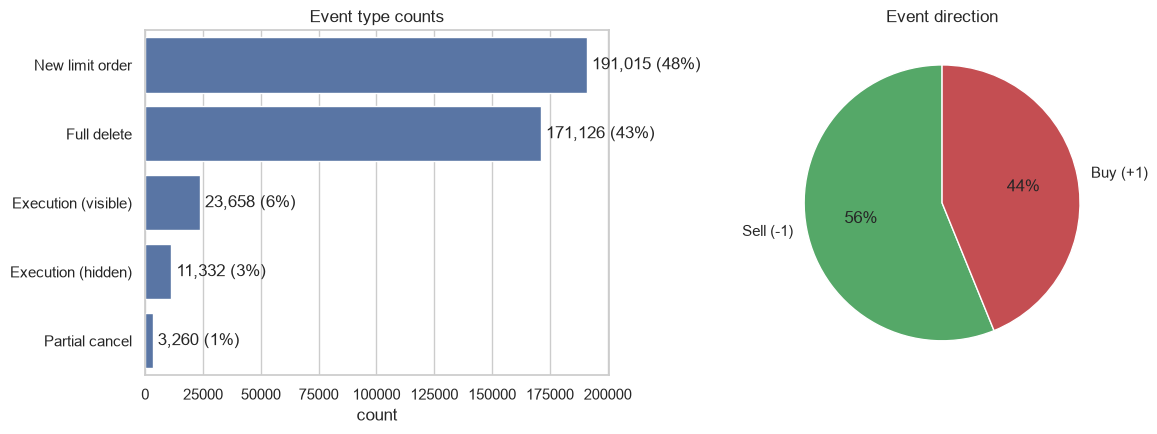

Executions are 8.7% of all events (23,658 visible + 11,332 hidden)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

event_counts = df_msg["event_label"].value_counts()
sns.barplot(x=event_counts.values, y=event_counts.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Event type counts")
axes[0].set_xlabel("count")
axes[0].set_ylabel("")
for i, v in enumerate(event_counts.values):
    axes[0].text(v, i, f" {v:,} ({v/len(df_msg):.0%})", va="center")

direction_counts = df_msg["direction"].map({1: "Buy (+1)", -1: "Sell (-1)"}).value_counts()
axes[1].pie(direction_counts.values, labels=direction_counts.index, autopct="%1.0f%%",
            colors=["#55A868", "#C44E52"], startangle=90)
axes[1].set_title("Event direction")

plt.tight_layout()
plt.show()

trades = df_msg[df_msg["event_type"].isin([4, 5])]
print(f"Executions are {len(trades)/len(df_msg):.1%} of all events "
      f"({(df_msg['event_type']==4).sum():,} visible + {(df_msg['event_type']==5).sum():,} hidden)")

## 4. Intraday activity pattern

Bucket events into 1-minute bins across the session. Equity markets famously trade in a
**U-shape**: heavy activity right at the open and into the close, quieter through the
midday lull.

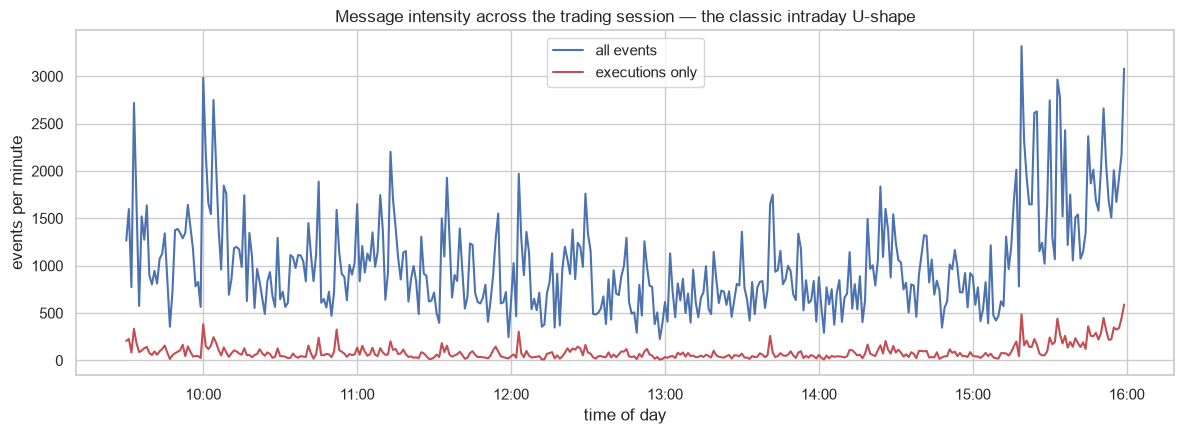

In [5]:
events_per_min = df_msg.set_index("time").resample("1min").size()
trades_per_min = trades.set_index("time").resample("1min").size()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(events_per_min.index, events_per_min.values, label="all events", color="#4C72B0")
ax.plot(trades_per_min.index, trades_per_min.values, label="executions only", color="#C44E52")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time of day")
ax.set_ylabel("events per minute")
ax.set_title("Message intensity across the trading session — the classic intraday U-shape")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Event inter-arrival times

The time gap between consecutive events. In real markets this is **not** exponential /
memoryless — activity clusters in bursts (algorithms firing in quick sequences), so we
expect a heavy right tail even on a log scale, and a spike near zero from same-timestamp
or sub-millisecond bursts.

count    400390.000000
mean         58.442790
std         208.833216
min           0.000000
25%           0.073261
50%           0.638858
75%           9.319839
max        8155.205382
Name: time_sec, dtype: float64

Median gap: 0.639 ms | 99th pct: 997.8 ms


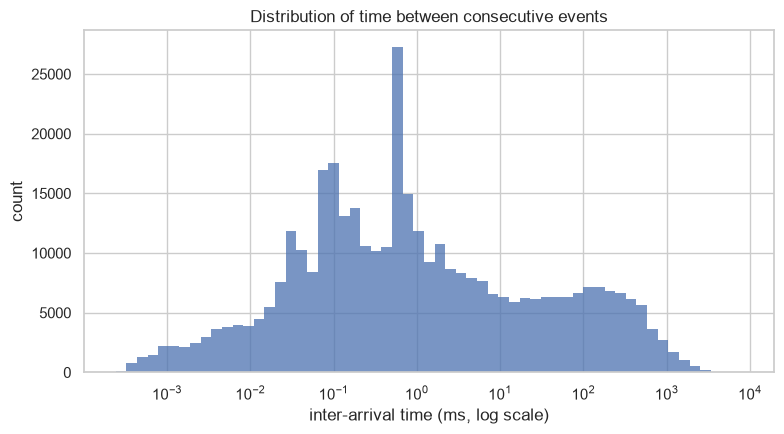

In [6]:
inter_arrival = df_msg["time_sec"].diff().dropna()
inter_arrival_ms = inter_arrival * 1000

print(inter_arrival_ms.describe())
print(f"\nMedian gap: {inter_arrival_ms.median():.3f} ms | 99th pct: {inter_arrival_ms.quantile(0.99):.1f} ms")

fig, ax = plt.subplots(figsize=(8, 4.5))
positive = inter_arrival_ms[inter_arrival_ms > 0]
sns.histplot(positive, bins=np.logspace(np.log10(positive.min()), np.log10(positive.max()), 60),
             ax=ax, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("inter-arrival time (ms, log scale)")
ax.set_ylabel("count")
ax.set_title("Distribution of time between consecutive events")
plt.tight_layout()
plt.show()

## 6. Mid-price and spread

Two of the most fundamental derived series in market microstructure:

- **mid-price** = (best bid + best ask) / 2 — the reference "fair value" proxy
- **spread** = best ask − best bid — the cost of demanding immediacy; compensation
  liquidity providers earn for standing ready to trade

We also express spread **in ticks** (spread ÷ $0.01), since on NASDAQ the spread is
constrained to be a whole number of ticks.

count    400391.000000
mean        583.152849
std           2.834982
min         577.480000
25%         581.245000
50%         583.235000
75%         585.660000
max         588.185000
Name: mid_price, dtype: float64

count    400391.000000
mean         15.348894
std           7.415759
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          92.000000
Name: spread_ticks, dtype: float64


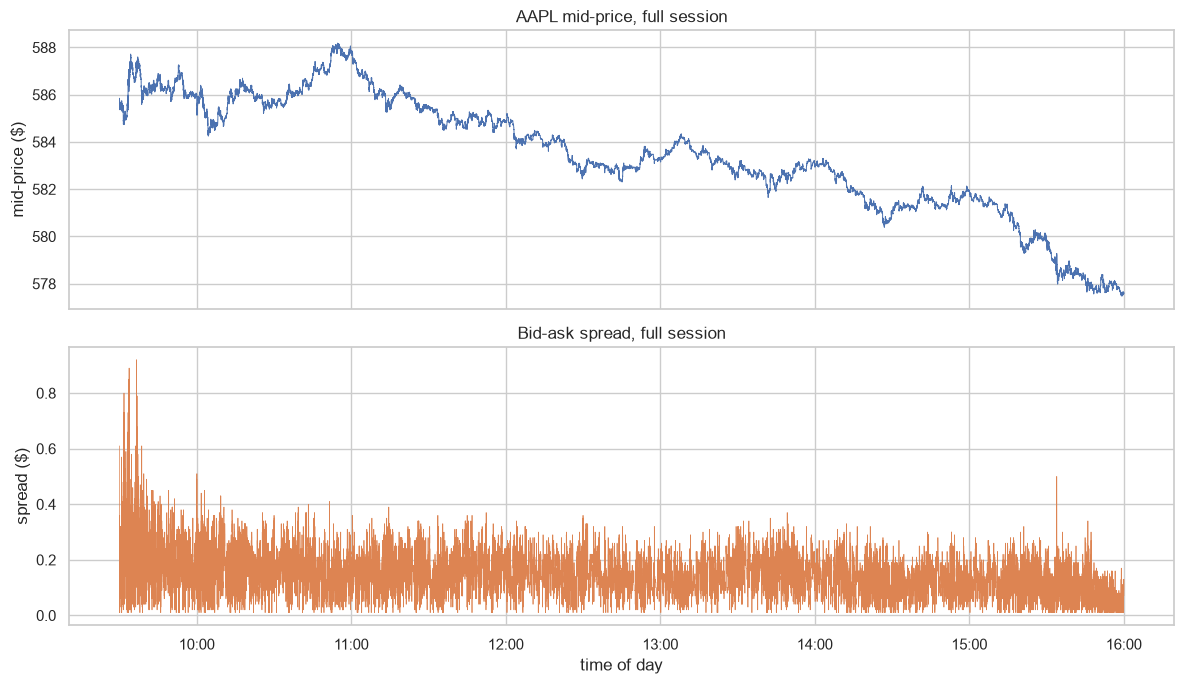

In [7]:
df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2
df["spread"] = df["ask_price_1"] - df["bid_price_1"]
df["spread_ticks"] = (df["spread"] / TICK).round().astype(int)

print(df["mid_price"].describe())
print()
print(df["spread_ticks"].describe())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df["time"], df["mid_price"], color="#4C72B0", linewidth=0.7)
axes[0].set_ylabel("mid-price ($)")
axes[0].set_title("AAPL mid-price, full session")

axes[1].plot(df["time"], df["spread"], color="#DD8452", linewidth=0.5)
axes[1].set_ylabel("spread ($)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_title("Bid-ask spread, full session")

plt.tight_layout()
plt.show()

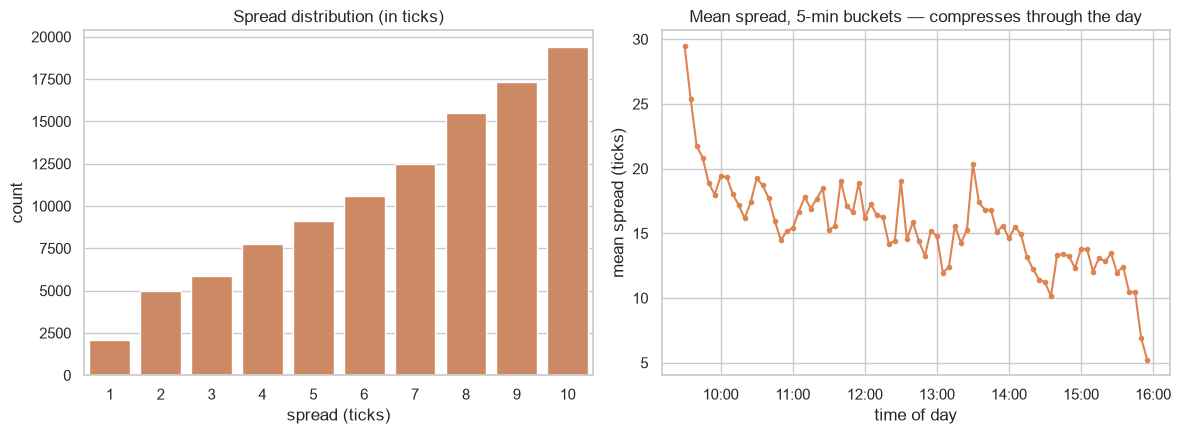

1-tick (minimum) spread holds 0.5% of the time


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

spread_counts = df["spread_ticks"].value_counts().sort_index().head(10)
sns.barplot(x=spread_counts.index, y=spread_counts.values, ax=axes[0], color="#DD8452")
axes[0].set_xlabel("spread (ticks)")
axes[0].set_ylabel("count")
axes[0].set_title("Spread distribution (in ticks)")

spread_by_min = df.set_index("time")["spread_ticks"].resample("5min").mean()
axes[1].plot(spread_by_min.index, spread_by_min.values, color="#DD8452", marker="o", markersize=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("mean spread (ticks)")
axes[1].set_title("Mean spread, 5-min buckets — compresses through the day")

plt.tight_layout()
plt.show()

print(f"1-tick (minimum) spread holds {(df['spread_ticks']==1).mean():.1%} of the time")

## 7. Order book shape

Average resting size at each of the 10 levels, and a snapshot of the actual book at one
instant. Size typically grows away from the best price — the top of book is thin (it
absorbs the most competition) while deeper levels accumulate more resting size.

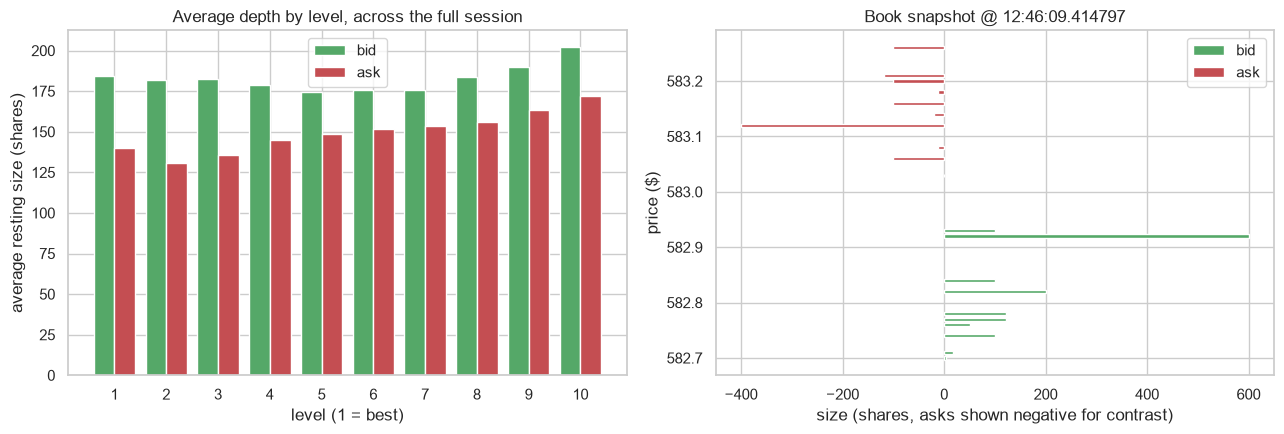

In [9]:
avg_bid_size = [df_ob[f"bid_size_{lvl}"].mean() for lvl in range(1, N_LEVELS + 1)]
avg_ask_size = [df_ob[f"ask_size_{lvl}"].mean() for lvl in range(1, N_LEVELS + 1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

levels = np.arange(1, N_LEVELS + 1)
width = 0.4
axes[0].bar(levels - width/2, avg_bid_size, width, label="bid", color="#55A868")
axes[0].bar(levels + width/2, avg_ask_size, width, label="ask", color="#C44E52")
axes[0].set_xlabel("level (1 = best)")
axes[0].set_ylabel("average resting size (shares)")
axes[0].set_title("Average depth by level, across the full session")
axes[0].set_xticks(levels)
axes[0].legend()

# Snapshot: the actual book at a single instant (midday)
snap_idx = df.index[len(df) // 2]
snap = df.loc[snap_idx]
bid_prices = [snap[f"bid_price_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
bid_sizes = [snap[f"bid_size_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
ask_prices = [snap[f"ask_price_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
ask_sizes = [snap[f"ask_size_{lvl}"] for lvl in range(1, N_LEVELS + 1)]

axes[1].barh(bid_prices, bid_sizes, height=0.006, color="#55A868", label="bid")
axes[1].barh(ask_prices, [-s for s in ask_sizes], height=0.006, color="#C44E52", label="ask")
axes[1].set_xlabel("size (shares, asks shown negative for contrast)")
axes[1].set_ylabel("price ($)")
axes[1].set_title(f"Book snapshot @ {snap['time'].time()}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Order book imbalance vs. future price moves

**Order book imbalance (OBI)** at the top of book:

$$\text{OBI} = \frac{\text{bid\_size}_1 - \text{ask\_size}_1}{\text{bid\_size}_1 + \text{ask\_size}_1} \in [-1, 1]$$

Positive OBI means more resting buy interest than sell interest at the best prices — a
textbook short-horizon signal that price should tick **up** next (more buyers waiting =
sellers get lifted first), and vice versa. We check this by binning OBI at each event and
looking at the mid-price change over the next 50 events.

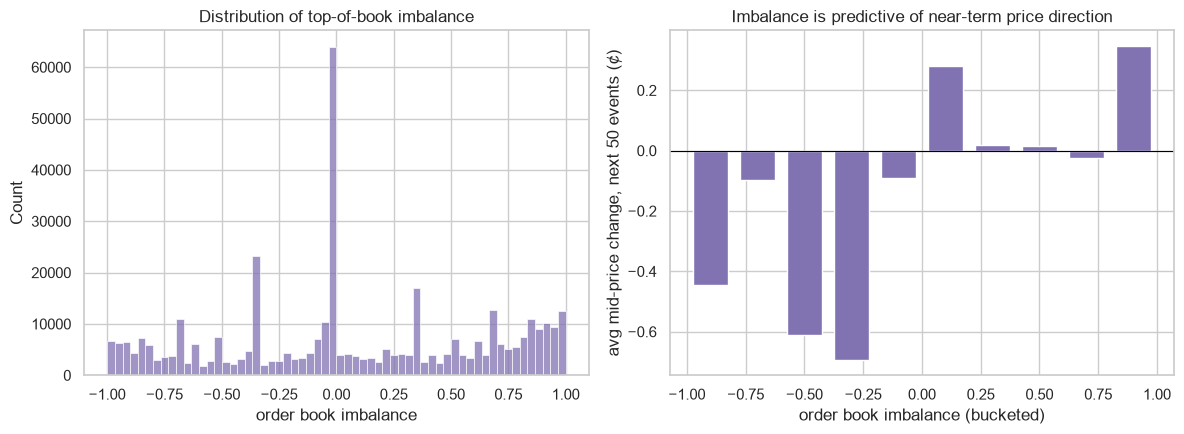

Correlation(OBI, future mid-price change): 0.0442


In [10]:
df["obi"] = (df["bid_size_1"] - df["ask_size_1"]) / (df["bid_size_1"] + df["ask_size_1"])

HORIZON = 50  # events ahead
df["future_mid_change"] = df["mid_price"].shift(-HORIZON) - df["mid_price"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["obi"], bins=60, ax=axes[0], color="#8172B2")
axes[0].set_xlabel("order book imbalance")
axes[0].set_title("Distribution of top-of-book imbalance")

valid = df.dropna(subset=["future_mid_change"]).copy()
valid["obi_bin"] = pd.cut(valid["obi"], bins=np.linspace(-1, 1, 11))
binned = valid.groupby("obi_bin", observed=True)["future_mid_change"].mean() * 100  # in cents
bin_centers = [interval.mid for interval in binned.index]

axes[1].bar(bin_centers, binned.values, width=0.15, color="#8172B2")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("order book imbalance (bucketed)")
axes[1].set_ylabel(f"avg mid-price change, next {HORIZON} events (¢)")
axes[1].set_title("Imbalance is predictive of near-term price direction")

plt.tight_layout()
plt.show()

print("Correlation(OBI, future mid-price change):", valid["obi"].corr(valid["future_mid_change"]).round(4))

## 9. Trades: size, sign, and volume profile

Filtering to executions only (`event_type` 4 or 5). Recall `direction = -1` on an
execution means a **resting sell** order was hit → the trade was **buyer-initiated**;
`direction = 1` means seller-initiated.

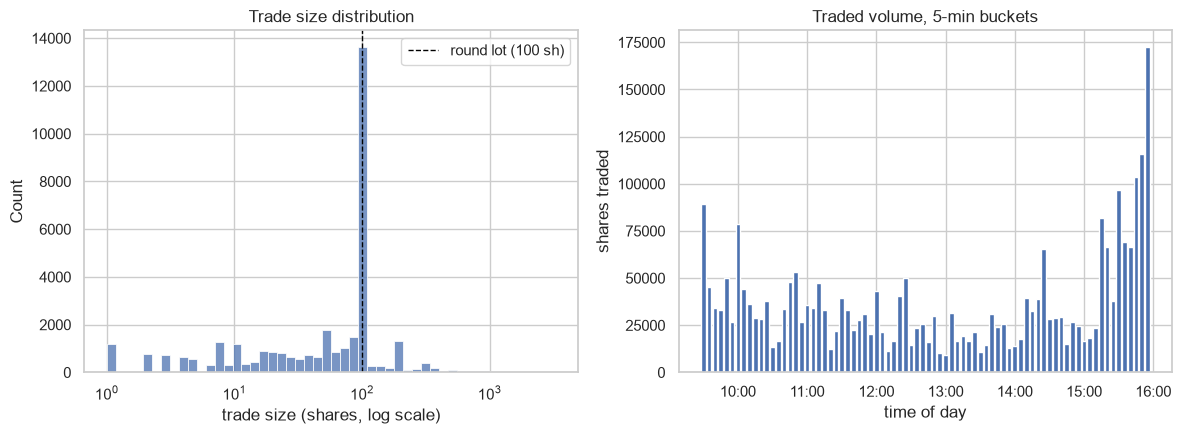

                  count      sum       mean
initiator                                  
buyer-initiated   16729  1314336  78.566322
seller-initiated  18261  1535804  84.102952

% of executed volume that is buyer-initiated: 46.1%


In [11]:
trades = trades.copy()
trades["initiator"] = trades["direction"].map({-1: "buyer-initiated", 1: "seller-initiated"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(trades["size"], bins=50, log_scale=(True, False), ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("trade size (shares, log scale)")
axes[0].set_title("Trade size distribution")
axes[0].axvline(100, color="black", linestyle="--", linewidth=1, label="round lot (100 sh)")
axes[0].legend()

volume_by_min = trades.set_index("time").groupby(pd.Grouper(freq="5min"))["size"].sum()
axes[1].bar(volume_by_min.index, volume_by_min.values, width=0.0028, color="#4C72B0")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("shares traded")
axes[1].set_title("Traded volume, 5-min buckets")

plt.tight_layout()
plt.show()

print(trades.groupby("initiator")["size"].agg(["count", "sum", "mean"]))
print(f"\n% of executed volume that is buyer-initiated: "
      f"{trades.loc[trades['initiator']=='buyer-initiated','size'].sum() / trades['size'].sum():.1%}")

## 10. New limit order sizes

Order sizes tend to cluster on **round lots** (multiples of 100 shares) — a well-known
artifact of how both human traders and execution algorithms slice orders.

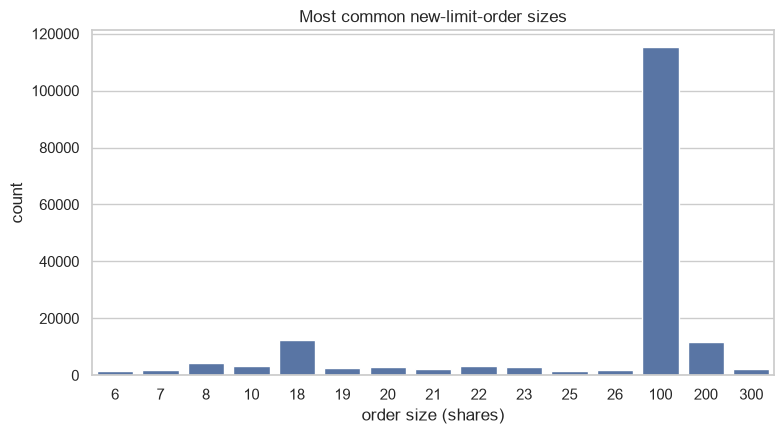

Share of new orders that are an exact multiple of 100 shares: 68.6%


In [12]:
new_orders = df_msg[df_msg["event_type"] == 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
top_sizes = new_orders["size"].value_counts().head(15).sort_index()
sns.barplot(x=top_sizes.index.astype(str), y=top_sizes.values, ax=ax, color="#4C72B0")
ax.set_xlabel("order size (shares)")
ax.set_ylabel("count")
ax.set_title("Most common new-limit-order sizes")
plt.tight_layout()
plt.show()

round_lot_share = (new_orders["size"] % 100 == 0).mean()
print(f"Share of new orders that are an exact multiple of 100 shares: {round_lot_share:.1%}")

## Summary

- ~400k events over one session; **new orders (48%)** and **full deletes (43%)** dominate,
  executions are under 9% — the book churns far more than it trades.
- Message intensity and traded volume both show the classic **intraday U-shape**: busy
  at the open, quiet at midday, busiest of all into the close.
- Event inter-arrival times are **heavy-tailed / bursty**, not memoryless — consistent
  with clustered, algorithmic order flow rather than a simple Poisson process.
- The spread is **not** pinned at the 1-tick minimum here — that only happens 0.5% of
  the time. Instead it **compresses steadily through the day**, from a wide ~26 ticks
  (~$0.26) right after the open down to ~7 ticks by the close, with a session median
  around 15 ticks (~$0.15) on a ~$583 stock.
- Book depth **grows away from the touch** — level 1 is thin, deeper levels hold more
  resting size.
- **Order book imbalance predicts short-horizon price direction**: buy-heavy books tend
  to tick up next, sell-heavy books tick down — the correlation is modest but
  directionally consistent, which is exactly the kind of signal high-frequency market
  making strategies exploit.
- Order sizes cluster heavily on **round lots** (69% of new orders are exact multiples
  of 100 shares); buyer- and seller-initiated trade volume are roughly balanced (46%/54%).

### Natural next steps
- Extend this pipeline to the 1/5/30/50-level files or other tickers (AMZN, GOOG, INTC,
  MSFT, SPY) to compare liquidity profiles across names.
- Build a feature set (OBI at multiple levels, queue position, realized volatility,
  trade-flow imbalance) for a short-horizon price-direction model.
- Model the event stream itself with a **Hawkes process** to capture the self-exciting
  clustering seen in the inter-arrival plot.